# Chapter 4. ECG signal Processing

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Import libraries

To install libraries in Python, you can use a package manager like pip, which comes pre-installed with most Python distributions.



In [ ]:
from matplotlib import pyplot as plt
import pandas as pd
from scipy import signal

## Import Dataset

In [ ]:
# load the Excel file as a DataFrame
eeg_data = pd.read_excel("/content/drive/MyDrive/Book_AI_for_Bio_Science/Scripts/dataset/signal_processing/ECG.xlsx")
display(eeg_data.head())

,data_1ch_test,data_2ch_test,data_3ch_test,data_4ch_test,data_5ch_test,data_6ch_test,data_7ch_test,data_8ch_test
0,-42130.80,-8620.35,56038.86,1182729.26,1182098.94,18030.61,1182073.45,1184034.42
1,-42142.07,-8673.46,56062.46,1182786.39,1182140.24,18050.73,1182130.59,1184070.36
2,-42162.18,-8691.97,56064.34,1182841.64,1182179.67,18038.66,1182185.57,1184104.16
3,-42182.30,-8689.55,56046.91,1182898.77,1182220.98,18002.72,1182240.82,1184139.29
4,-42190.61,-8698.94,56031.62,1182952.95,1182260.67,17977.51,1182294.74,1184171.48


Before applying filtering or advanced analysis techniques to electromyography (EMG) signals, it is essential to first visualize the raw data. Plotting the unprocessed EMG signal provides crucial insight into the quality and characteristics of the recording. Raw EMG data often contains noise, motion artifacts, baseline drift, and disturbances from external electrical sources. By examining the unprocessed waveform, we can quickly detect issues such as poor electrode placement, loose connections, unexpected spikes, or saturation of the amplifier.

Understanding the shape, amplitude, and timing of the raw EMG helps us decide what type of processing is required and ensures that we do not unintentionally distort meaningful physiological information. For example, identifying the frequency content, noise sources, or periods of muscle activation becomes much easier when the signal is first viewed in its natural form. Plotting raw data is therefore a fundamental step that guides filter selection, segmentation, normalization, and feature extraction.

In short, visualizing raw EMG data ensures the quality of the recording, prevents incorrect interpretation, and provides a reliable foundation for all later stages of EMG signal processing.

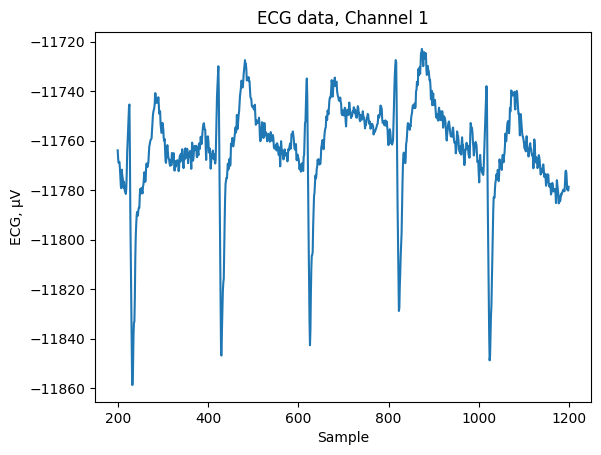

In [ ]:
# select the data from the first channel
channel = 0
channel_data = eeg_data.iloc[:, channel]
channel_data = round(1000000*4.5*(channel_data/16777215),2)  # Convert data from ADC to µV

# plot the EEG data
plt.plot(channel_data[200:1200])
plt.title("ECG data, Channel " + str(channel+1))
plt.ylabel('ECG, µV')
plt.xlabel('Sample')
plt.show()

The raw EMG-contaminated signal demonstrates several important characteristics that highlight why initial visualization is essential before applying signal-processing techniques. The recording shows a clear baseline drift, indicating slow changes in electrode or skin impedance, as well as prominent high-frequency bursts and sharp transients produced by intentional muscle activations performed in a 4-3-2-1 sequence. These bursts dominate the waveform and create strong amplitude fluctuations typical of EMG interference. The combination of drift, noise, and high-intensity muscle activity makes this dataset an ideal example of a “dirty” raw signal, illustrating the need for preprocessing steps such as detrending, filtering, and segmentation. This graph effectively demonstrates the challenges of working with real physiological data and provides a valuable foundation for teaching EMG signal-processing methods.

**Signal Processing**  
In physiological signal analysis, raw recordings such as EEG or EMG often contain unwanted components that can obscure the true activity of interest. Before we extract features or interpret muscle or brain activity, it is essential to perform basic preprocessing, a stage of signal processing focused on cleaning and preparing the data

**What is better band pass filter is better or worse and sometimes**


**1. Band-pass filter**

Purpose:

Isolates the physiological EMG signal by keeping the main frequency range (usually 20–450 Hz) and removing low- and high-frequency noise.

When to use:

Always as the first preprocessing step for raw EMG.

Necessary when the signal contains:

Low-frequency drift or motion artifacts (<20 Hz)

High-frequency noise (>450 Hz)

Power line interference (can combine with notch filter)

Key point: Band-pass preserves both amplitude and frequency content of EMG, making it suitable for both amplitude and frequency analyses.

**2. Zero-meaning (DC offset removal)**

Purpose:

Removes the mean or DC offset from the EMG signal, centering it around zero.

When to use:

When electrodes or amplifiers introduce baseline drift.

Often done after band-pass filtering but before rectification.

Key point: Zero-meaning does not remove frequency-specific noise; it only corrects baseline shifts.

**3. Rectification of EMG**

Purpose:

Converts all negative values of the EMG signal to positive values.

When to use:

Required for amplitude-based analyses, e.g.:

RMS (root mean square) calculation

Envelope detection

Muscle activation timing

Key point: Rectification is not used for frequency analysis because it changes the spectral content.

**4. Rectified filter / Envelope extraction**

Purpose:

Applies a low-pass filter to the rectified EMG to produce a smooth envelope of muscle activity.

When to use:

To visualize temporal patterns of muscle activation.

To quantify activation onset/offset or average muscle activity over time.

Key point: This step is for temporal/amplitude analysis, not raw signal frequency content.

**Summary Table: When to Use Each Step**  
Step	When to Use / Purpose  
Band-pass filter	First step; remove motion artifacts (<20 Hz) and high-frequency noise (>450 Hz)  
Zero-meaning	Remove baseline drift; often after band-pass, before rectification  
Rectification	Convert to all-positive for amplitude analysis (RMS, envelope)  
Rectified filter / envelope	Smooth rectified signal to visualize/quantify muscle activation patterns  

💡 Rule of thumb:

Band-pass filter → clean raw EMG

Zero-meaning → fix baseline

Rectification → prepare for amplitude-based analysis

Low-pass smoothing / envelope → extract temporal trends

**Conclusion**

To ensure accurate analysis, a sequential preprocessing pipeline is recommended. Band-pass filtering (typically 20–450 Hz) is applied first to isolate the physiological EMG frequency range while removing irrelevant low- and high-frequency components. Zero-meaning is then used to remove DC offsets and baseline drift. For amplitude-based analyses, the signal is rectified, converting all negative values to positive, and subsequently a low-pass filter is applied to the rectified signal to extract the EMG envelope, highlighting temporal patterns of muscle activation. This approach ensures a clean signal, preserves relevant physiological information, and enables robust quantification of muscle activity in both amplitude and temporal domains.

**Notch filter for EMG**

This script implements a digital filtering pipeline using Butterworth high-pass and low-pass filters, combined with a 50 Hz notch filter. The high-pass filter removes low-frequency baseline drift and movement artifacts, the notch filter eliminates mains power interference, and the low-pass filter attenuates high-frequency noise. Together, these filters preserve the physiological EMG signal within its characteristic frequency range, improving signal quality for subsequent analysis such as amplitude, frequency, and envelope detection. The script also provides a visualization of the filtered signal to facilitate verification of preprocessing effectiveness.

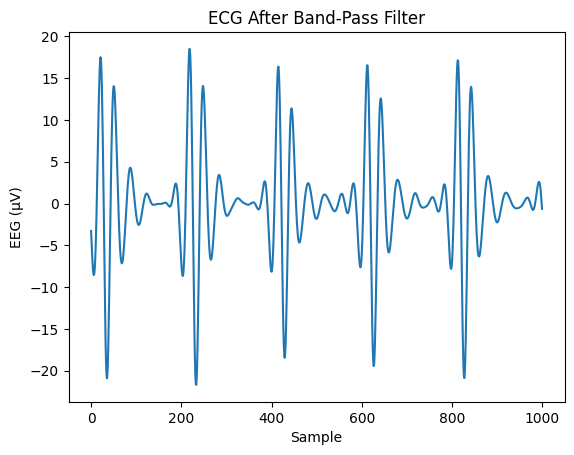

In [ ]:
from scipy import signal
import matplotlib.pyplot as plt

# ------------------------------------------------------
# High-pass filter
# ------------------------------------------------------
def butter_highpass_filter(data, cutoff, nyq, order=5):
    normal_cutoff = cutoff / nyq
    b, a = signal.butter(order, normal_cutoff, btype='high', analog=False)
    filtered_data = signal.filtfilt(b, a, data)
    return filtered_data

# ------------------------------------------------------
# Low-pass filter
# ------------------------------------------------------
def butter_lowpass_filter(data, cutoff, nyq, order=5):
    normal_cutoff = cutoff / nyq
    b, a = signal.butter(order, normal_cutoff, btype='low', analog=False)
    filtered_data = signal.filtfilt(b, a, data)
    return filtered_data

# ------------------------------------------------------
# 50 Hz Notch Filter
# ------------------------------------------------------
def notch_filter(data, notch_freq, fs, Q=30):
    """
    notch_freq: frequency to remove (50 Hz)
    fs: sampling rate
    Q: quality factor (20-50 typical)
    """
    b, a = signal.iirnotch(w0=notch_freq, Q=Q, fs=fs)
    filtered_data = signal.filtfilt(b, a, data)
    return filtered_data

# ------------------------------------------------------
# Apply filters
# ------------------------------------------------------
channel_data_filtered = channel_data.copy()

fs = 250                # sampling frequency
nyq = fs * 0.5          # Nyquist
notch_freq = 50         # 50 Hz mains interference
Q = 30                  # notch filter sharpness

# Optional: high-pass + notch + low-pass
cutoff_high = 5         # example HP cutoff
cutoff_low = 10        # example LP cutoff

# 1. High-pass
channel_data_filtered = butter_highpass_filter(
    data=channel_data_filtered,
    cutoff=cutoff_high,
    nyq=nyq,
    order=5
)


# 3. Low-pass
channel_data_filtered = butter_lowpass_filter(
    data=channel_data_filtered,
    cutoff=cutoff_low,
    nyq=nyq,
    order=4
)

# ------------------------------------------------------
# Plot result
# ------------------------------------------------------
plt.plot(channel_data_filtered[200:1200])
plt.title("ECG After Band-Pass Filter")
plt.ylabel("EEG (µV)")
plt.xlabel("Sample")
plt.show()


**R peak detection via Peak Detection**

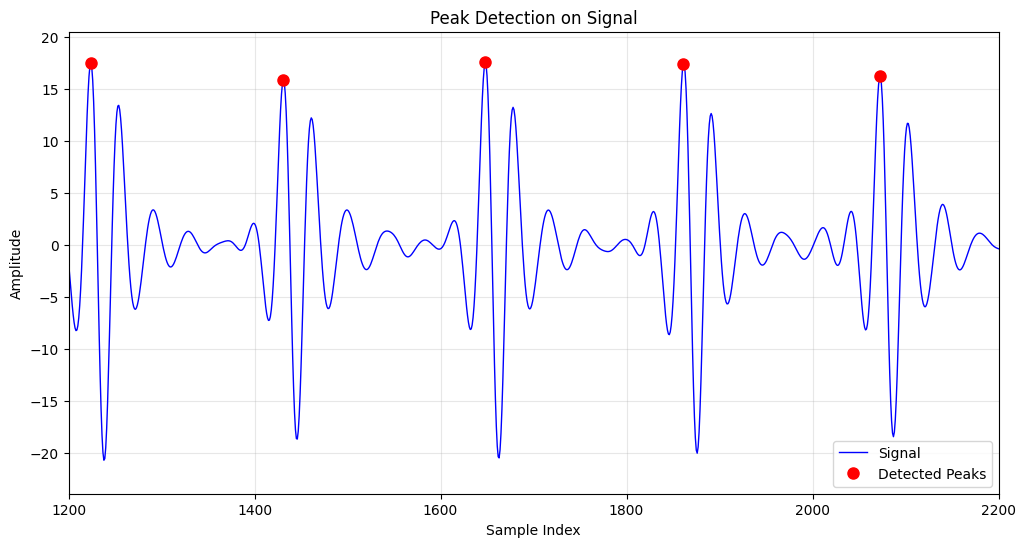

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# Your signal data (replace with full array or load from file)
x =channel_data_filtered
# Create x-axis (sample indices)
n_samples = len(x)
time = np.arange(n_samples)

# Detect peaks (local maxima)
peaks, _ = find_peaks(x, height=15.0)  # Adjust height threshold as needed for your data

# Plot
plt.figure(figsize=(12, 6))
plt.plot(time, x, 'b-', linewidth=1, label='Signal')
plt.plot(time[peaks], x[peaks], 'ro', markersize=8, label='Detected Peaks')

plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.title('Peak Detection on Signal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim([1200,2200])
plt.show()

#print(f"Detected {len(peaks)} peaks at indices: {peaks}")
#print(f"Peak values: {x[peaks]}")


**R detection without Thershold**

In [ ]:
!pip install neurokit2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 708.4/708.4 kB 42.8 MB/s eta 0:00:00


In [ ]:
!pip install neurokit2


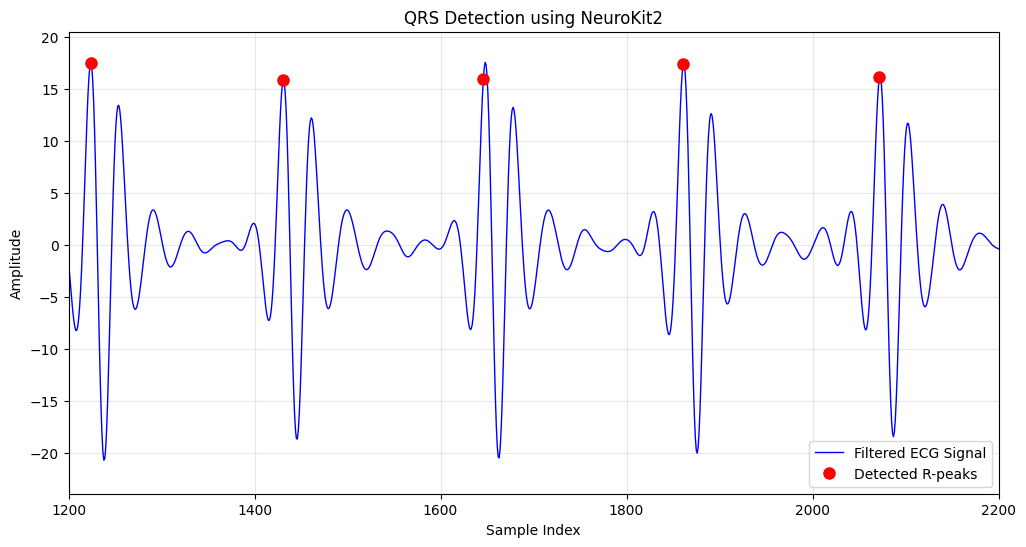

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import neurokit2 as nk

# Your filtered ECG signal
x = channel_data_filtered

# Sampling rate (IMPORTANT – adjust to your data)
fs = 360  # Hz (common values: 250, 360, 500)

# Create time axis (in samples)
n_samples = len(x)
time = np.arange(n_samples)

# --- QRS (R-peak) detection ---
# This uses a validated ECG algorithm (Pan-Tompkins / wavelet-based)
signals, info = nk.ecg_process(x, sampling_rate=fs)

# Extract R-peak indices
r_peaks = info["ECG_R_Peaks"]

# --- Plot ---
plt.figure(figsize=(12, 6))
plt.plot(time, x, 'b-', linewidth=1, label='Filtered ECG Signal')
plt.plot(r_peaks, x[r_peaks], 'ro', markersize=8, label='Detected R-peaks')

plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.title('QRS Detection using NeuroKit2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim([1200, 2200])
plt.show()

# Optional prints
# print(f"Detected {len(r_peaks)} R-peaks")
# print(f"R-peak indices: {r_peaks}")


R peak kdetection

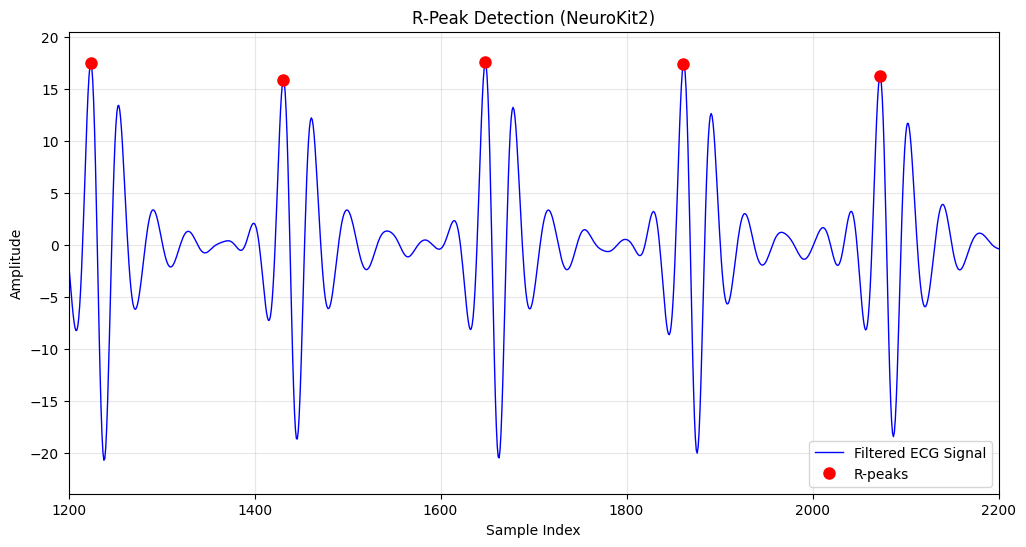

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import neurokit2 as nk

x = channel_data_filtered
fs = 360

time = np.arange(len(x))

# Detect R-peaks only
_, info = nk.ecg_peaks(x, sampling_rate=fs)

r_peaks = info["ECG_R_Peaks"]

plt.figure(figsize=(12, 6))
plt.plot(time, x, 'b-', linewidth=1, label='Filtered ECG Signal')
plt.plot(r_peaks, x[r_peaks], 'ro', markersize=8, label='R-peaks')

plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.title('R-Peak Detection (NeuroKit2)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim([1200, 2200])
plt.show()


**QRS duration**

In [ ]:
import numpy as np
import neurokit2 as nk

ecg = channel_data_filtered
fs = 250  # Hz

# R-peak detection
signals, info = nk.ecg_process(ecg, sampling_rate=fs)

# ECG delineation
_, delineate_info = nk.ecg_delineate(
    ecg,
    rpeaks=info["ECG_R_Peaks"],
    sampling_rate=fs,
    method="dwt"
)

# Convert lists → numpy arrays
q_peaks = np.array(delineate_info["ECG_Q_Peaks"], dtype=float)
s_peaks = np.array(delineate_info["ECG_S_Peaks"], dtype=float)

# Remove NaNs
valid = (~np.isnan(q_peaks)) & (~np.isnan(s_peaks))
q_peaks = q_peaks[valid].astype(int)
s_peaks = s_peaks[valid].astype(int)

# QRS duration (ms)
qrs_duration_ms = (s_peaks - q_peaks) / fs * 1000

print("QRS durations (ms):")
print(qrs_duration_ms)
print(f"\nMean QRS duration: {np.mean(qrs_duration_ms):.2f} ms")


QRS durations (ms):
[116. 120. 116. 116. 116. 120. 124. 124. 120. 120. 124. 120. 116. 120.
 116. 120. 120. 116. 116. 116. 120. 120. 116. 116. 116. 116. 116. 120.
 120. 120. 120. 120. 120. 120. 120. 116. 120. 120. 120. 116. 116. 120.
 116. 120. 120. 116. 120. 120. 120. 116. 116. 116. 116. 116. 116. 120.
 120. 120. 120. 120. 116. 116. 120. 120. 116. 120. 120. 120. 120. 120.
 116. 116. 120. 116. 116. 120. 116. 120. 116. 120. 120. 120. 116. 120.
 116. 120. 116. 116. 116. 116. 120. 116. 116. 116. 116. 116. 120.]

Mean QRS duration: 118.27 ms


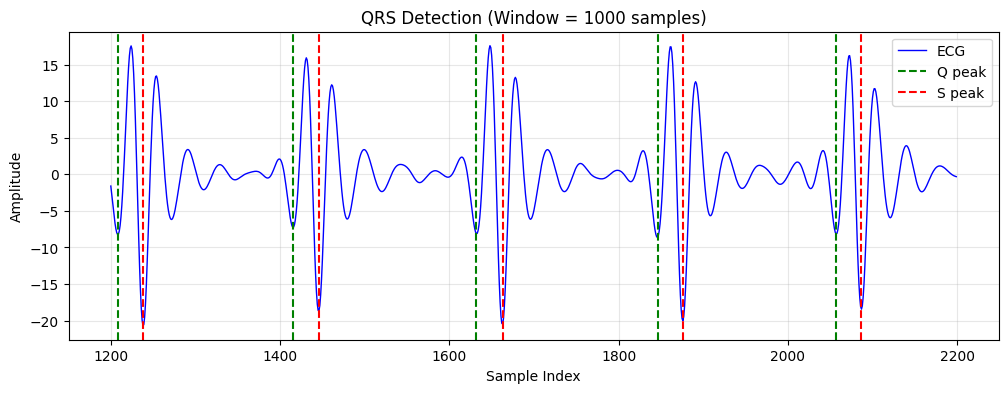

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- Parameters ---
window_len = 1000
start = 1200          # choose start index
end = start + window_len

# Safety
end = min(len(ecg), end)

# --- Select Q & S peaks inside the window ---
q_in_window = q_peaks[(q_peaks >= start) & (q_peaks < end)]
s_in_window = s_peaks[(s_peaks >= start) & (s_peaks < end)]

# --- Plot ---
plt.figure(figsize=(12, 4))

plt.plot(range(start, end), ecg[start:end], 'b', linewidth=1, label="ECG")

# Plot ALL Q peaks (green)
for i, q in enumerate(q_in_window):
    plt.axvline(q, color='g', linestyle='--', linewidth=1.5,
                label='Q peak' if i == 0 else "")

# Plot ALL S peaks (red)
for i, s in enumerate(s_in_window):
    plt.axvline(s, color='r', linestyle='--', linewidth=1.5,
                label='S peak' if i == 0 else "")

plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.title(f"QRS Detection (Window = {window_len} samples)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()


**RR interval**

RR intervals (ms):
[788. 788. 788. 800. 848. 828. 860. 860. 844. 860. 860. 836. 832. 824.
 812. 820. 820. 816. 840. 828. 852. 828. 824. 824. 808. 812. 816. 820.
 816. 820. 848. 824. 824. 836. 812. 816. 812. 792. 792. 800. 796. 812.
 828. 836. 836. 832. 828. 796. 796. 796. 800. 816. 812. 824. 820. 832.
 828. 816. 840. 808. 812. 800. 804. 800. 828. 844. 836. 840. 840. 804.
 812. 808. 800. 808. 824. 800. 820. 816. 804. 812. 804. 792. 792. 796.
 804. 796. 820. 800. 780. 796. 800. 796. 800. 796. 804. 796. 684.]
Mean RR interval: 814.93 ms


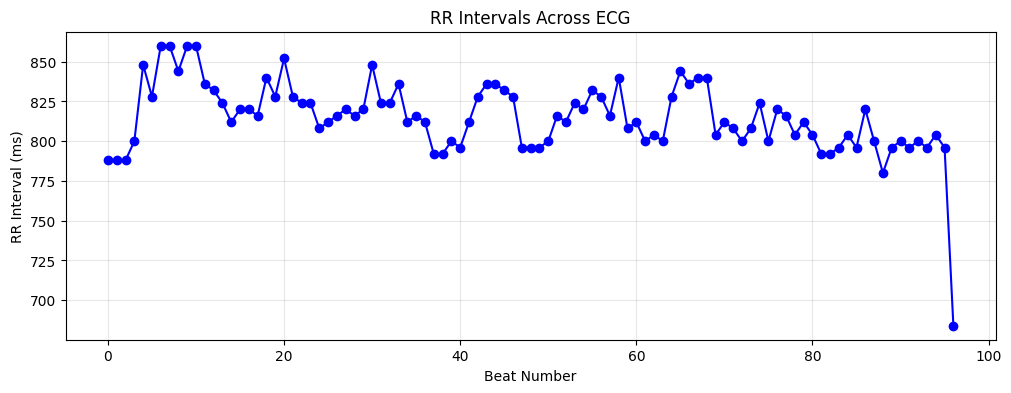

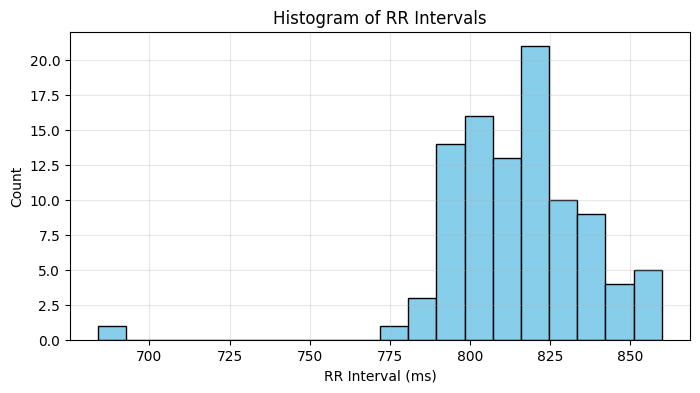

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import neurokit2 as nk

# --- 1. Load your filtered ECG ---
ecg = channel_data_filtered  # your filtered ECG signal
fs = 250                  # sampling rate in Hz (adjust to your data)

# --- 2. Detect R-peaks using NeuroKit2 ---
signals, info = nk.ecg_process(ecg, sampling_rate=fs)
r_peaks = info["ECG_R_Peaks"]  # indices of R-peaks

# --- 3. Calculate RR intervals (in seconds) ---
rr_intervals = np.diff(r_peaks) / fs  # diff between consecutive R-peaks
# Convert to milliseconds if you want
rr_intervals_ms = rr_intervals * 1000

print(f"RR intervals (ms):\n{rr_intervals_ms}")
print(f"Mean RR interval: {np.mean(rr_intervals_ms):.2f} ms")

# --- 4. Plot RR intervals ---
plt.figure(figsize=(12, 4))
plt.plot(rr_intervals_ms, marker='o', linestyle='-', color='b')
plt.xlabel("Beat Number")
plt.ylabel("RR Interval (ms)")
plt.title("RR Intervals Across ECG")
plt.grid(alpha=0.3)
plt.show()

# --- 5. Optional: Histogram of RR intervals ---
plt.figure(figsize=(8, 4))
plt.hist(rr_intervals_ms, bins=20, color='skyblue', edgecolor='k')
plt.xlabel("RR Interval (ms)")
plt.ylabel("Count")
plt.title("Histogram of RR Intervals")
plt.grid(alpha=0.3)
plt.show()


PQ interval

PR intervals (ms):
[ 60.  64.  64.  64.  64.  64.  68.  72.  72.  64.  68.  68.  64.  68.
  64.  60.  60.  64.  64.  64.  64.  64.  64.  64.  60.  64.  64.  60.
  64.  60.  60.  64.  64.  60.  64.  60.  60.  60.  64.  60.  60.  60.
  64.  64.  60.  64.  60.  60.  60.  60.  64.  60.  60.  64.  60.  60.
  64.  60.  60.  64.  60.  60.  60.  60.  60.  60.  64.  64.  64.  64.
  60.  60.  60.  56.  64.  60.  60.  60.  60.  60.  60.  60.  60.  56.
  60.  56.  64.  60.  64.  56.  56.  60.  60.  60.  60.  60.  60. 172.]
Mean PQ interval: 62.98 ms


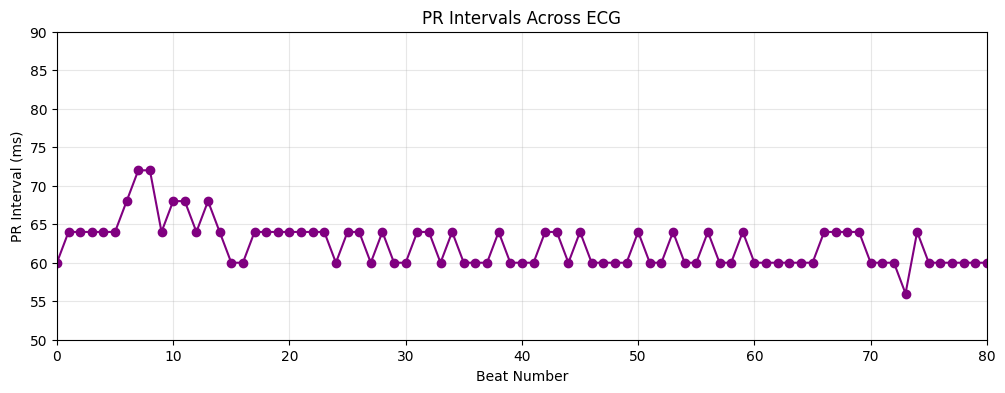

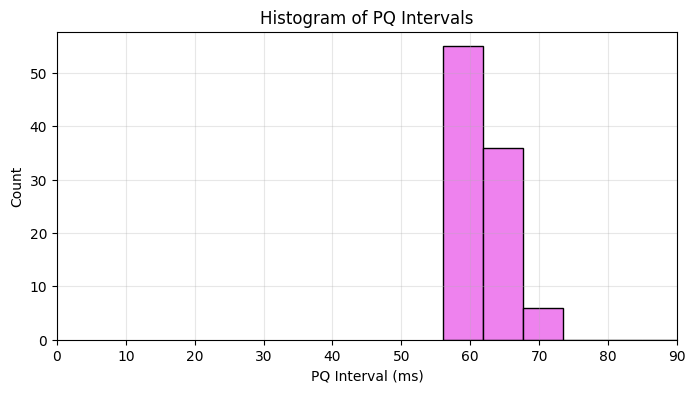

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import neurokit2 as nk

# --- 1. Load your filtered ECG ---
ecg = channel_data_filtered  # your filtered ECG signal
fs = 250                   # sampling rate in Hz (adjust to your data)

# --- 2. Detect R-peaks using NeuroKit2 ---
signals, info = nk.ecg_process(ecg, sampling_rate=fs)

# --- 3. Delineate ECG to get P and Q peaks ---
_, delineate_info = nk.ecg_delineate(
    ecg,
    rpeaks=info["ECG_R_Peaks"],
    sampling_rate=fs,
    method="dwt"
)

# Convert to numpy arrays
p_peaks = np.array(delineate_info["ECG_P_Peaks"], dtype=float)
q_peaks = np.array(delineate_info["ECG_Q_Peaks"], dtype=float)

# Remove missing detections (NaN)
valid = (~np.isnan(p_peaks)) & (~np.isnan(q_peaks))
p_peaks = p_peaks[valid].astype(int)
q_peaks = q_peaks[valid].astype(int)

# --- 4. Calculate PR intervals in milliseconds ---
pr_intervals_ms = (q_peaks - p_peaks) / fs * 1000

print(f"PR intervals (ms):\n{pr_intervals_ms}")
print(f"Mean PQ interval: {np.mean(pr_intervals_ms):.2f} ms")

# --- 5. Plot PR intervals across ECG ---
plt.figure(figsize=(12, 4))
plt.plot(pr_intervals_ms, marker='o', linestyle='-', color='purple')
plt.xlabel("Beat Number")
plt.ylabel("PR Interval (ms)")
plt.title("PR Intervals Across ECG")
plt.grid(alpha=0.3)
plt.xlim([0, 80])
plt.ylim([50,90])
plt.show()

# --- 6. Optional: Histogram of PR intervals ---
plt.figure(figsize=(8, 4))
plt.hist(pr_intervals_ms, bins=20, color='violet', edgecolor='k')
plt.xlabel("PQ Interval (ms)")
plt.ylabel("Count")
plt.title("Histogram of PQ Intervals")
plt.grid(alpha=0.3)
plt.xlim([0, 90])
plt.show()


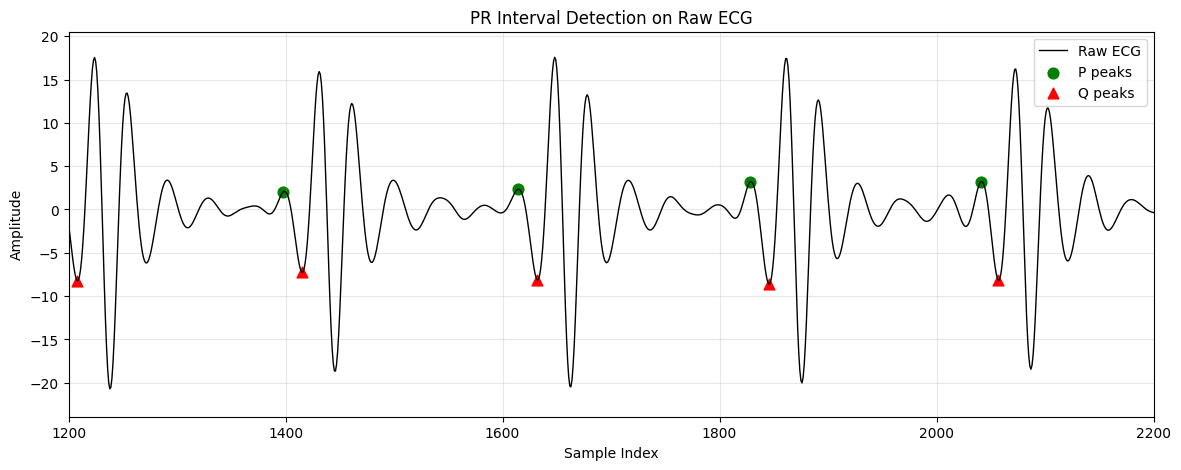

In [ ]:
plt.figure(figsize=(14, 5))

# Plot raw ECG
plt.plot(ecg, label="Raw ECG", color="black", linewidth=1)

# Overlay P peaks
plt.scatter(p_peaks, ecg[p_peaks],
            color="green", marker="o", s=60, label="P peaks")

# Overlay Q peaks
plt.scatter(q_peaks, ecg[q_peaks],
            color="red", marker="^", s=60, label="Q peaks")

plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.title("PR Interval Detection on Raw ECG")
plt.legend()
plt.grid(alpha=0.3)
plt.xlim([1200, 2200])
plt.show()


**QT Interval Calculation**

QT intervals (ms):
[232. 236. 228. 236. 228. 240. 244. 240. 236. 240. 240. 240. 236. 236.
 232. 240. 240. 232. 232. 232. 236. 236. 236. 232. 232. 236. 236. 236.
 236. 236. 236. 240. 240. 240. 240. 236. 240. 240. 240. 232. 236. 236.
 232. 240. 236. 236. 240. 236. 236. 232. 236. 236. 236. 236. 236. 240.
 236. 236. 240. 240. 236. 232. 236. 240. 232. 240. 240. 240. 240. 240.
 232. 236. 240. 236. 240. 236. 236. 236. 236. 240. 240. 236. 236. 244.
 236. 240. 236. 236. 236. 236. 244. 236. 236. 236. 236. 236. 240.]
Mean QT interval: 236.82 ms


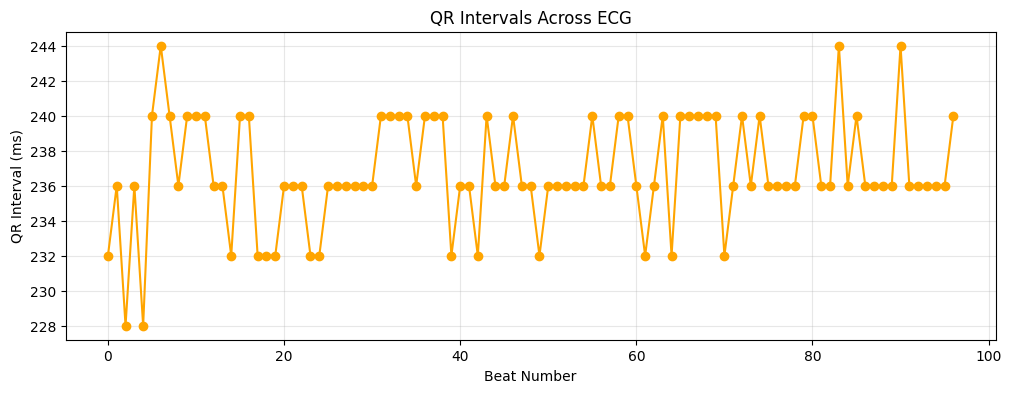

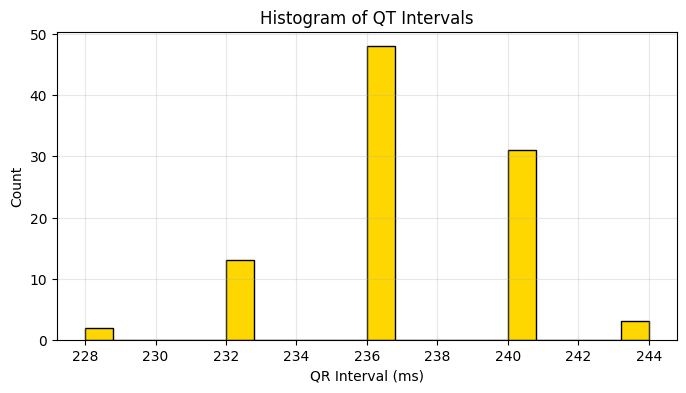

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import neurokit2 as nk

# --- 1. Load your filtered ECG ---
ecg = channel_data_filtered  # your filtered ECG signal
fs = 250                # sampling rate in Hz (adjust to your data)

# --- 2. Detect R-peaks using NeuroKit2 ---
signals, info = nk.ecg_process(ecg, sampling_rate=fs)

# --- 3. Delineate ECG to get Q peaks and T offsets ---
_, delineate_info = nk.ecg_delineate(
    ecg,
    rpeaks=info["ECG_R_Peaks"],
    sampling_rate=fs,
    method="dwt"
)

# Convert to numpy arrays
q_peaks = np.array(delineate_info["ECG_Q_Peaks"], dtype=float)
t_offsets = np.array(delineate_info["ECG_T_Offsets"], dtype=float)

# Remove missing detections (NaN)
valid = (~np.isnan(q_peaks)) & (~np.isnan(t_offsets))
q_peaks = q_peaks[valid].astype(int)
t_offsets = t_offsets[valid].astype(int)

# --- 4. Calculate QT intervals in milliseconds ---
qt_intervals_ms = (t_offsets - q_peaks) / fs * 1000

print(f"QT intervals (ms):\n{qt_intervals_ms}")
print(f"Mean QT interval: {np.mean(qt_intervals_ms):.2f} ms")

# --- 5. Plot QT intervals across ECG ---
plt.figure(figsize=(12, 4))
plt.plot(qt_intervals_ms, marker='o', linestyle='-', color='orange')
plt.xlabel("Beat Number")
plt.ylabel("QR Interval (ms)")
plt.title("QR Intervals Across ECG")
plt.grid(alpha=0.3)
plt.show()

# --- 6. Optional: Histogram of QT intervals ---
plt.figure(figsize=(8, 4))
plt.hist(qt_intervals_ms, bins=20, color='gold', edgecolor='k')
plt.xlabel("QR Interval (ms)")
plt.ylabel("Count")
plt.title("Histogram of QT Intervals")
plt.grid(alpha=0.3)
plt.show()


Graph Visualisation

QT intervals (ms):
[161.11111111 163.88888889 161.11111111 163.88888889 161.11111111
 166.66666667 169.44444444 166.66666667 163.88888889 166.66666667
 166.66666667 166.66666667 163.88888889 163.88888889 161.11111111
 166.66666667 166.66666667 161.11111111 161.11111111 161.11111111
 163.88888889 163.88888889 163.88888889 161.11111111 161.11111111
 163.88888889 163.88888889 163.88888889 163.88888889 163.88888889
 163.88888889 166.66666667 166.66666667 166.66666667 166.66666667
 163.88888889 166.66666667 166.66666667 166.66666667 161.11111111
 163.88888889 163.88888889 161.11111111 166.66666667 163.88888889
 163.88888889 166.66666667 163.88888889 163.88888889 161.11111111
 163.88888889 163.88888889 163.88888889 163.88888889 163.88888889
 166.66666667 163.88888889 163.88888889 166.66666667 166.66666667
 163.88888889 161.11111111 163.88888889 166.66666667 161.11111111
 166.66666667 166.66666667 166.66666667 166.66666667 166.66666667
 161.11111111 163.88888889 166.66666667 163.88888889 166.

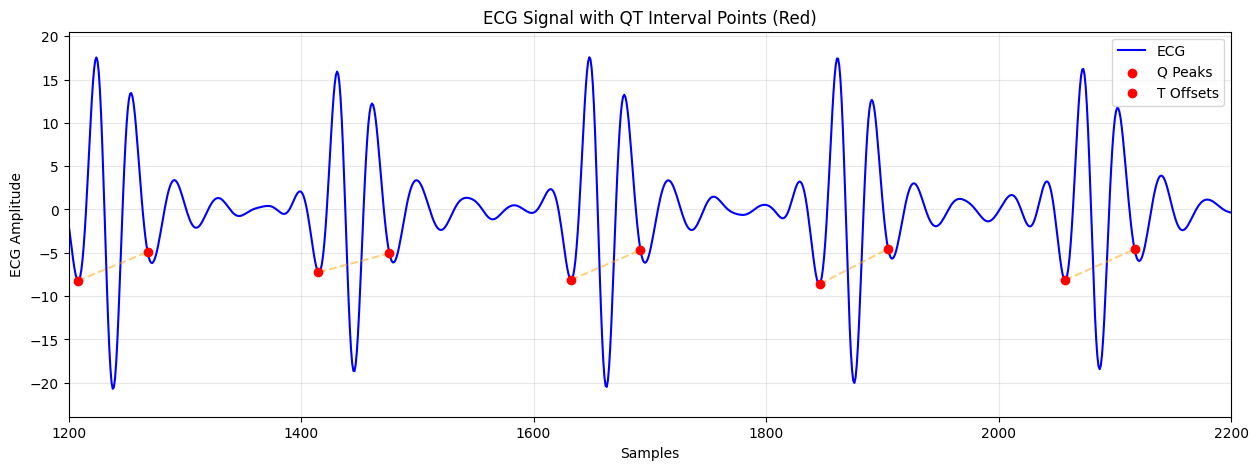

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import neurokit2 as nk

# --- 1. Load your filtered ECG ---
ecg = channel_data_filtered  # your filtered ECG signal
fs = 360                     # sampling rate in Hz (adjust to your data)

# --- 2. Detect R-peaks using NeuroKit2 ---
signals, info = nk.ecg_process(ecg, sampling_rate=fs)

# --- 3. Delineate ECG to get Q peaks and T offsets ---
_, delineate_info = nk.ecg_delineate(
    ecg,
    rpeaks=info["ECG_R_Peaks"],
    sampling_rate=fs,
    method="dwt"
)

# Convert to numpy arrays
q_peaks = np.array(delineate_info["ECG_Q_Peaks"], dtype=float)
t_offsets = np.array(delineate_info["ECG_T_Offsets"], dtype=float)

# Remove missing detections (NaN)
valid = (~np.isnan(q_peaks)) & (~np.isnan(t_offsets))
q_peaks = q_peaks[valid].astype(int)
t_offsets = t_offsets[valid].astype(int)

# --- 4. Calculate QT intervals in milliseconds ---
qt_intervals_ms = (t_offsets - q_peaks) / fs * 1000

print(f"QT intervals (ms):\n{qt_intervals_ms}")
print(f"Mean QT interval: {np.mean(qt_intervals_ms):.2f} ms")

# --- 5. Plot ECG with Q peaks and T offsets as red points ---
plt.figure(figsize=(15, 5))
plt.plot(ecg, color='blue', label='ECG')
plt.scatter(q_peaks, ecg[q_peaks], color='red', label='Q Peaks', zorder=5)
plt.scatter(t_offsets, ecg[t_offsets], color='red', label='T Offsets', zorder=5)

# Optionally connect each Q-T pair with a dashed line
for q, t in zip(q_peaks, t_offsets):
    plt.plot([q, t], [ecg[q], ecg[t]], color='orange', linestyle='--', alpha=0.5)

plt.xlabel("Samples")
plt.ylabel("ECG Amplitude")
plt.title("ECG Signal with QT Interval Points (Red)")
plt.legend()
plt.grid(alpha=0.3)
plt.xlim([1200, 2200])
plt.show()


**indicate points**

QT intervals (ms):
[161.11111111 163.88888889 161.11111111 163.88888889 161.11111111
 166.66666667 169.44444444 166.66666667 163.88888889 166.66666667
 166.66666667 166.66666667 163.88888889 163.88888889 161.11111111
 166.66666667 166.66666667 161.11111111 161.11111111 161.11111111
 163.88888889 163.88888889 163.88888889 161.11111111 161.11111111
 163.88888889 163.88888889 163.88888889 163.88888889 163.88888889
 163.88888889 166.66666667 166.66666667 166.66666667 166.66666667
 163.88888889 166.66666667 166.66666667 166.66666667 161.11111111
 163.88888889 163.88888889 161.11111111 166.66666667 163.88888889
 163.88888889 166.66666667 163.88888889 163.88888889 161.11111111
 163.88888889 163.88888889 163.88888889 163.88888889 163.88888889
 166.66666667 163.88888889 163.88888889 166.66666667 166.66666667
 163.88888889 161.11111111 163.88888889 166.66666667 161.11111111
 166.66666667 166.66666667 166.66666667 166.66666667 166.66666667
 161.11111111 163.88888889 166.66666667 163.88888889 166.

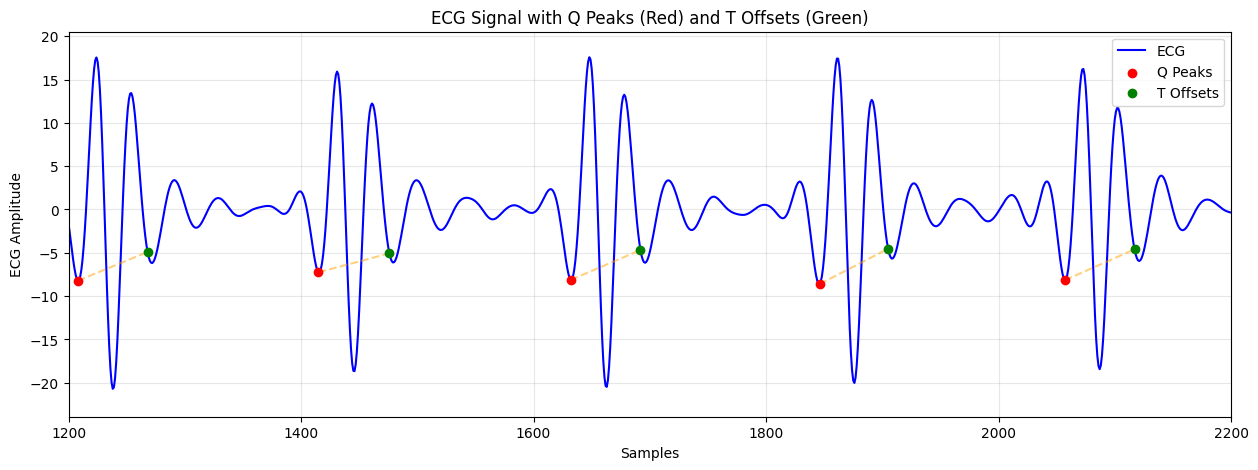

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import neurokit2 as nk

# --- 1. Load your filtered ECG ---
ecg = channel_data_filtered  # your filtered ECG signal
fs = 360                     # sampling rate in Hz

# --- 2. Detect R-peaks ---
signals, info = nk.ecg_process(ecg, sampling_rate=fs)

# --- 3. Delineate ECG to get Q peaks and T offsets ---
_, delineate_info = nk.ecg_delineate(
    ecg,
    rpeaks=info["ECG_R_Peaks"],
    sampling_rate=fs,
    method="dwt"
)

# Convert to numpy arrays
q_peaks = np.array(delineate_info["ECG_Q_Peaks"], dtype=float)
t_offsets = np.array(delineate_info["ECG_T_Offsets"], dtype=float)

# Remove missing detections (NaN)
valid = (~np.isnan(q_peaks)) & (~np.isnan(t_offsets))
q_peaks = q_peaks[valid].astype(int)
t_offsets = t_offsets[valid].astype(int)

# --- 4. Calculate QT intervals in milliseconds ---
qt_intervals_ms = (t_offsets - q_peaks) / fs * 1000
print(f"QT intervals (ms):\n{qt_intervals_ms}")
print(f"Mean QT interval: {np.mean(qt_intervals_ms):.2f} ms")

# --- 5. Plot ECG with Q peaks and T offsets ---
plt.figure(figsize=(15, 5))
plt.plot(ecg, color='blue', label='ECG')
plt.scatter(q_peaks, ecg[q_peaks], color='red', label='Q Peaks', zorder=5)
plt.scatter(t_offsets, ecg[t_offsets], color='green', label='T Offsets', zorder=5)

# Optionally draw vertical lines for each QT interval
for q, t in zip(q_peaks, t_offsets):
    plt.plot([q, t], [ecg[q], ecg[t]], color='orange', linestyle='--', alpha=0.5)

plt.xlabel("Samples")
plt.ylabel("ECG Amplitude")
plt.title("ECG Signal with Q Peaks (Red) and T Offsets (Green)")
plt.legend()
plt.grid(alpha=0.3)
plt.xlim([1200, 2200])
plt.show()


**ST segmentation**

ST segment levels (amplitude):
[7.77960964 7.0557101  5.73463439 7.70914467 6.68550444 7.99976523
 6.61606702 6.77510144 6.27491409 6.85115413 6.50584936 8.21414553
 7.21223095 6.35222714 8.09331167 6.81043667 6.30046828 8.312494
 6.55460778 7.2005571  6.86569323 7.2203702  6.31477987 6.85885117
 7.66830869 7.33555956 8.12158174 6.7385398  6.55208972 6.16064121
 7.01883237 7.87530807 6.51407507 7.40005091 7.76078951 7.16848563
 7.09197255 7.2415551  6.8167216  6.43165278 8.09738336 6.89327805
 5.67227863 7.99036487 5.90230798 7.11368649 7.38880534 6.30457693
 5.66434532 6.64556607 7.75258892 7.51291175 7.17864269 8.42081374
 7.17527173 6.78422985 6.58706484 6.35281728 6.3682145  7.30849706
 6.8977732  6.7453848  6.84689984 6.40406192 6.38185308 6.81786901
 6.43038339 6.91200695 7.54473601 7.1913921  5.72925063 8.32706272
 6.35168792 7.07797944 7.59126082 6.3319755  6.63978831 6.35592188
 6.85434722 6.52579178 6.93191926 7.05428507 6.58019702 7.39820592
 7.29974661 6.62384993 7.04767467

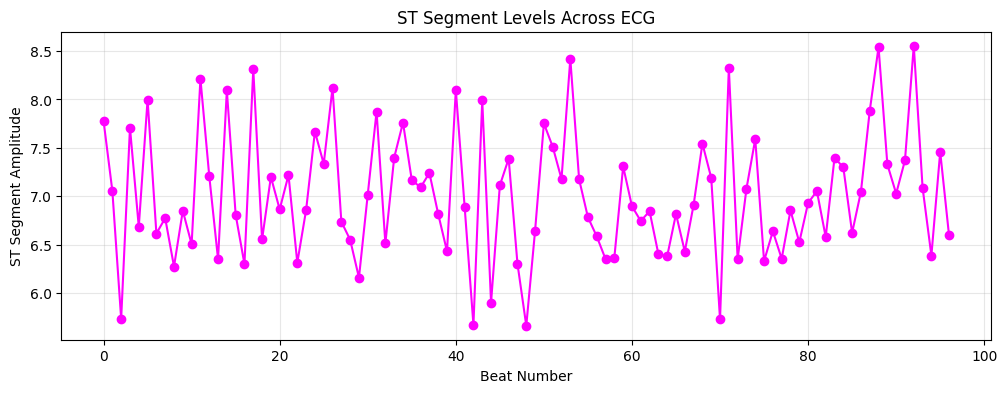

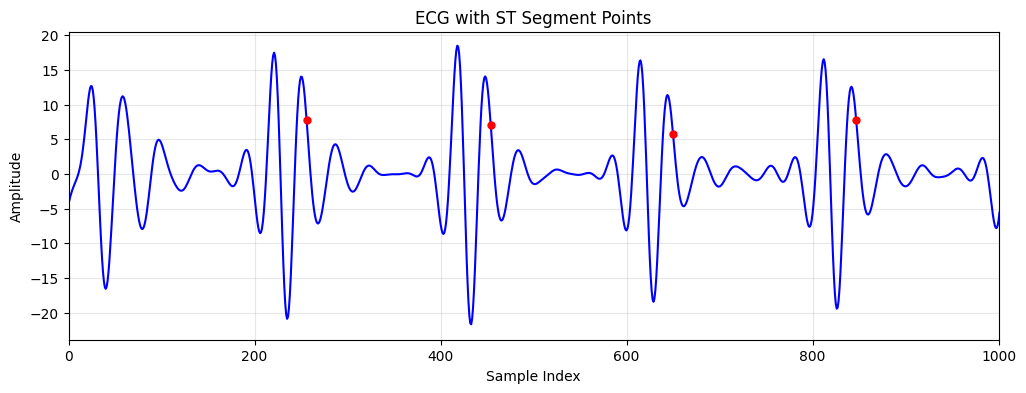

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import neurokit2 as nk

# --- 1. Load your filtered ECG ---
ecg = channel_data_filtered  # your filtered ECG signal
fs = 360                     # sampling rate in Hz (adjust to your data)

# --- 2. Detect R-peaks ---
signals, info = nk.ecg_process(ecg, sampling_rate=fs)
r_peaks = info["ECG_R_Peaks"]

# --- 3. Delineate ECG to get S peaks and T onsets ---
_, delineate_info = nk.ecg_delineate(
    ecg,
    rpeaks=r_peaks,
    sampling_rate=fs,
    method="dwt"
)

# Convert to numpy arrays
s_peaks = np.array(delineate_info["ECG_S_Peaks"], dtype=float)
t_onsets = np.array(delineate_info["ECG_T_Onsets"], dtype=float)

# Remove missing detections
valid = (~np.isnan(s_peaks)) & (~np.isnan(t_onsets))
s_peaks = s_peaks[valid].astype(int)
t_onsets = t_onsets[valid].astype(int)

# --- 4. Measure ST segment ---
# Standard: measure ST level 60-80 ms after S peak
st_offset_samples = int(0.06 * fs)  # 60 ms after S peak

st_levels = []
for s in s_peaks:
    idx = s + st_offset_samples
    if idx < len(ecg):
        st_levels.append(ecg[idx])
    else:
        st_levels.append(np.nan)

st_levels = np.array(st_levels)

print("ST segment levels (amplitude):")
print(st_levels)

# --- 5. Plot ST segment levels ---
plt.figure(figsize=(12, 4))
plt.plot(st_levels, marker='o', linestyle='-', color='magenta')
plt.xlabel("Beat Number")
plt.ylabel("ST Segment Amplitude")
plt.title("ST Segment Levels Across ECG")
plt.grid(alpha=0.3)\
#plt.xlim([0,1000])
plt.show()

# --- 6. Optional: Overlay ST points on ECG ---
plt.figure(figsize=(12, 4))
plt.plot(ecg, 'b', label="ECG")
for s, st in zip(s_peaks, st_levels):
    if not np.isnan(st):
        plt.plot(s + st_offset_samples, st, 'ro', markersize=5, label='ST Point')
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.title("ECG with ST Segment Points")
plt.grid(alpha=0.3)
plt.xlim([0,1000])
plt.show()


SDNN

SDNN (s): 0.0130 s
SDNN (ms): 12.96 ms


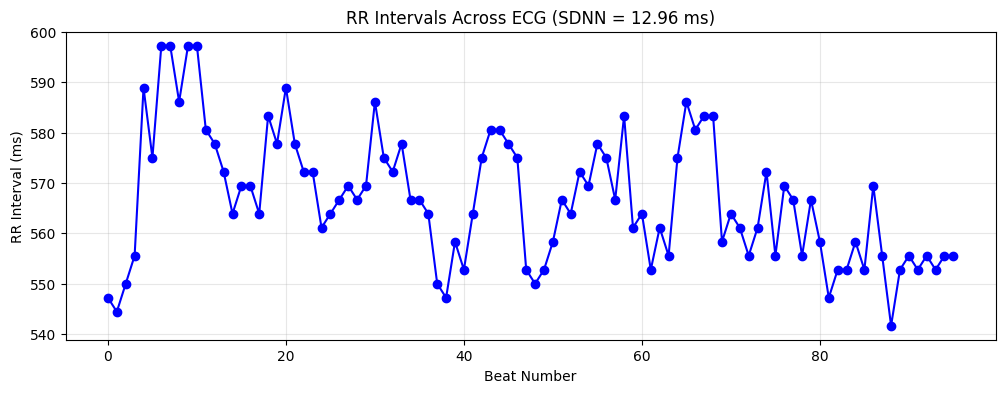

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import neurokit2 as nk

# --- 1. Load your filtered ECG ---
ecg = channel_data_filtered
fs = 360  # sampling rate in Hz (adjust to your data)

# --- 2. Detect R-peaks ---
signals, info = nk.ecg_process(ecg, sampling_rate=fs)
r_peaks = info["ECG_R_Peaks"]

# --- 3. Calculate RR intervals in seconds ---
rr_intervals = np.diff(r_peaks) / fs

# --- 4. Time-domain HRV metric: SDNN ---
sdnn = np.std(rr_intervals, ddof=1)  # standard deviation of RR intervals
print(f"SDNN (s): {sdnn:.4f} s")
print(f"SDNN (ms): {sdnn*1000:.2f} ms")

# --- 5. Optional: Plot RR intervals ---
plt.figure(figsize=(12, 4))
plt.plot(rr_intervals*1000, marker='o', linestyle='-', color='blue')
plt.xlabel("Beat Number")
plt.ylabel("RR Interval (ms)")
plt.title(f"RR Intervals Across ECG (SDNN = {sdnn*1000:.2f} ms)")
plt.grid(alpha=0.3)
plt.show()


SDNN (s): 0.0130 s
SDNN (ms): 12.96 ms


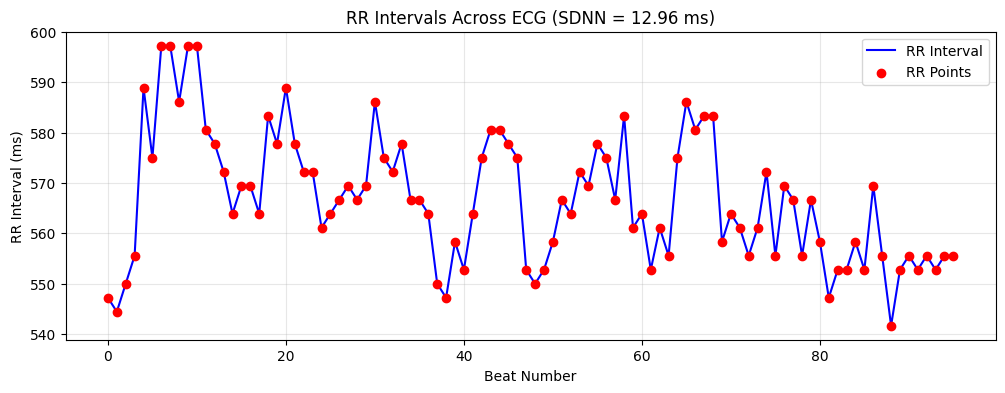

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import neurokit2 as nk

# --- 1. Load your filtered ECG ---
ecg = channel_data_filtered
fs = 360  # sampling rate in Hz (adjust to your data)

# --- 2. Detect R-peaks ---
signals, info = nk.ecg_process(ecg, sampling_rate=fs)
r_peaks = info["ECG_R_Peaks"]

# --- 3. Calculate RR intervals in seconds ---
rr_intervals = np.diff(r_peaks) / fs

# --- 4. Time-domain HRV metric: SDNN ---
sdnn = np.std(rr_intervals, ddof=1)  # standard deviation of RR intervals
print(f"SDNN (s): {sdnn:.4f} s")
print(f"SDNN (ms): {sdnn*1000:.2f} ms")

# --- 5. Plot RR intervals with red points ---
plt.figure(figsize=(12, 4))
plt.plot(rr_intervals*1000, linestyle='-', color='blue', label='RR Interval')
plt.scatter(range(len(rr_intervals)), rr_intervals*1000, color='red', label='RR Points', zorder=5)

plt.xlabel("Beat Number")
plt.ylabel("RR Interval (ms)")
plt.title(f"RR Intervals Across ECG (SDNN = {sdnn*1000:.2f} ms)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


RMSSD

RMSSD (s): 0.0101 s
RMSSD (ms): 10.10 ms


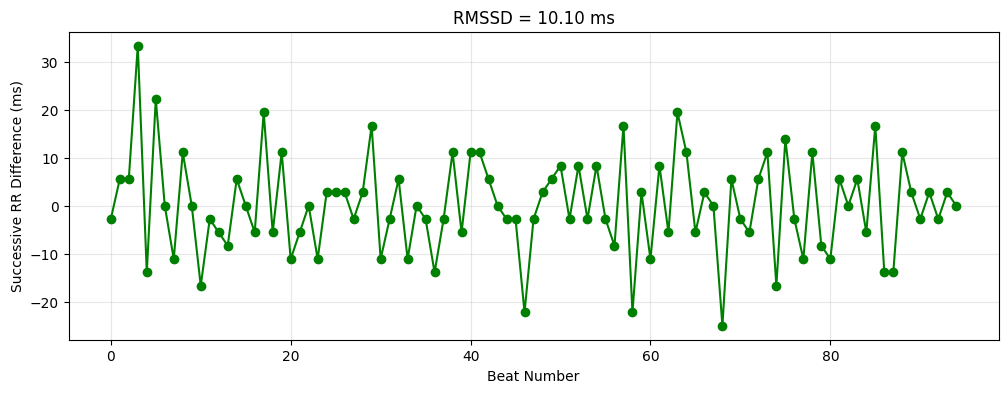

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import neurokit2 as nk

# --- 1. Load your filtered ECG ---
ecg = channel_data_filtered
fs = 360  # sampling rate in Hz

# --- 2. Detect R-peaks ---
signals, info = nk.ecg_process(ecg, sampling_rate=fs)
r_peaks = info["ECG_R_Peaks"]

# --- 3. Calculate RR intervals in seconds ---
rr_intervals = np.diff(r_peaks) / fs  # seconds

# --- 4. Calculate RMSSD ---
diff_rr = np.diff(rr_intervals)       # successive differences
rmssd = np.sqrt(np.mean(diff_rr**2))
print(f"RMSSD (s): {rmssd:.4f} s")
print(f"RMSSD (ms): {rmssd*1000:.2f} ms")

# --- 5. Optional: Plot successive RR differences ---
plt.figure(figsize=(12, 4))
plt.plot(diff_rr*1000, marker='o', linestyle='-', color='green')
plt.xlabel("Beat Number")
plt.ylabel("Successive RR Difference (ms)")
plt.title(f"RMSSD = {rmssd*1000:.2f} ms")
plt.grid(alpha=0.3)
plt.show()


**Frequency-domain: FFT-based LF/HF**

LF Power: 0.0000
HF Power: 0.0000
LF/HF Ratio: 1.3477


/tmp/ipython-input-3137414116.py:28: UserWarning: nperseg=256 is greater than signal length max(len(x), len(y)) = 216, using nperseg = 216
  f, psd = welch(rr_interp, fs=fs_interp, nperseg=256)
/tmp/ipython-input-3137414116.py:34: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  lf_power = np.trapz(psd[(f>=lf_band[0]) & (f<=lf_band[1])],
/tmp/ipython-input-3137414116.py:36: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  hf_power = np.trapz(psd[(f>=hf_band[0]) & (f<=hf_band[1])],


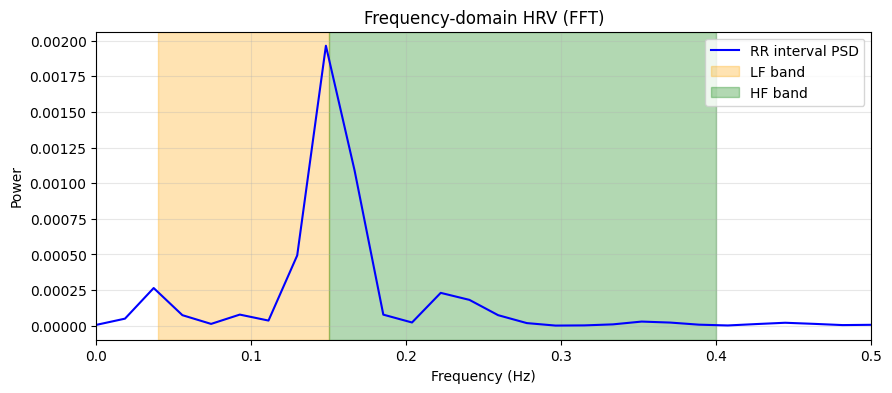

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import neurokit2 as nk
from scipy.signal import welch

# --- 1. Load your filtered ECG ---
ecg = channel_data_filtered
fs = 360  # sampling rate in Hz

# --- 2. Detect R-peaks ---
signals, info = nk.ecg_process(ecg, sampling_rate=fs)
r_peaks = info["ECG_R_Peaks"]

# --- 3. Calculate RR intervals in seconds ---
rr_intervals = np.diff(r_peaks) / fs  # seconds

# --- 4. Interpolate RR intervals to evenly spaced time series ---
# Required for FFT
rr_times = np.cumsum(rr_intervals)
rr_times = rr_times - rr_times[0]  # start at 0

# Interpolation to 4 Hz (common standard)
fs_interp = 4  # Hz
time_interp = np.arange(0, rr_times[-1], 1/fs_interp)
rr_interp = np.interp(time_interp, rr_times, rr_intervals)

# --- 5. FFT-based Power Spectral Density ---
f, psd = welch(rr_interp, fs=fs_interp, nperseg=256)

# --- 6. Define LF and HF bands ---
lf_band = (0.04, 0.15)  # Hz
hf_band = (0.15, 0.4)   # Hz

lf_power = np.trapz(psd[(f>=lf_band[0]) & (f<=lf_band[1])],
                    f[(f>=lf_band[0]) & (f<=lf_band[1])])
hf_power = np.trapz(psd[(f>=hf_band[0]) & (f<=hf_band[1])],
                    f[(f>=hf_band[0]) & (f<=hf_band[1])])

lf_hf_ratio = lf_power / hf_power

print(f"LF Power: {lf_power:.4f}")
print(f"HF Power: {hf_power:.4f}")
print(f"LF/HF Ratio: {lf_hf_ratio:.4f}")

# --- 7. Plot PSD with LF/HF bands ---
plt.figure(figsize=(10, 4))
plt.plot(f, psd, color='blue', label='RR interval PSD')
plt.axvspan(lf_band[0], lf_band[1], color='orange', alpha=0.3, label='LF band')
plt.axvspan(hf_band[0], hf_band[1], color='green', alpha=0.3, label='HF band')
plt.xlim(0, 0.5)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power')
plt.title('Frequency-domain HRV (FFT)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


**Discrete Wavelet Transform (DWT)**

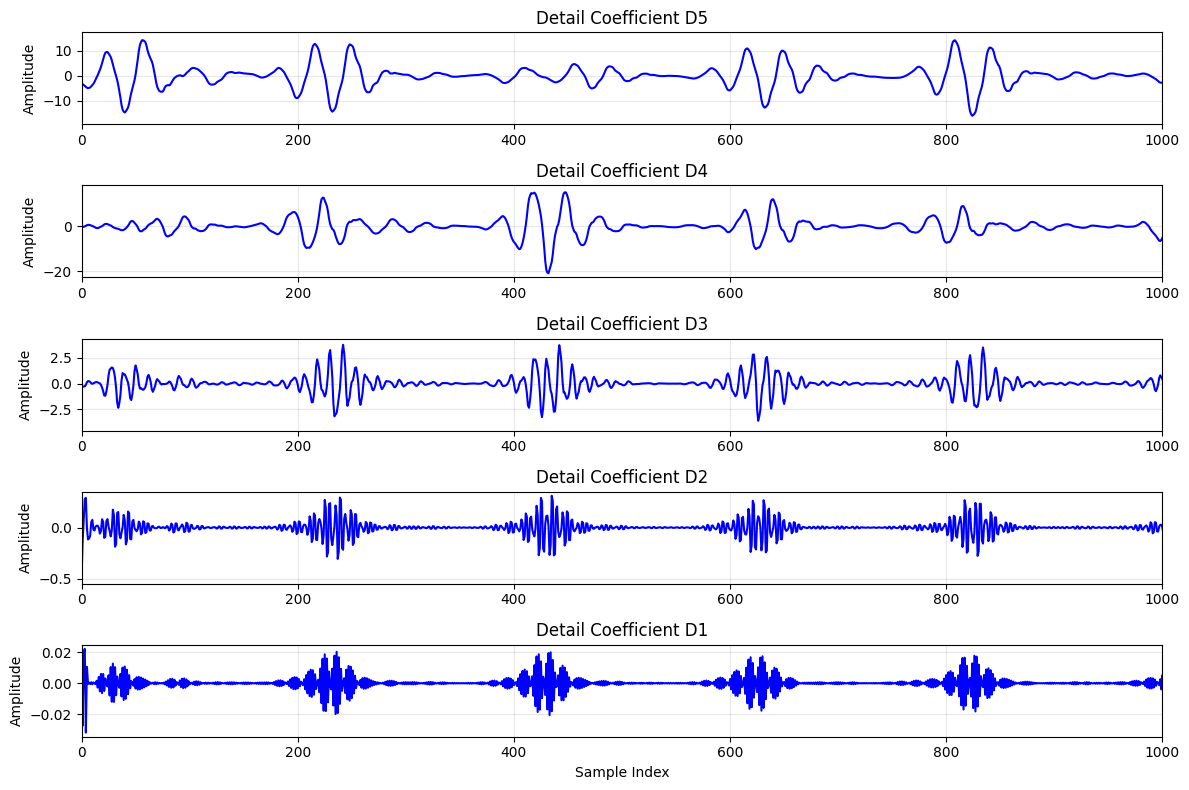

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pywt

# --- 1. Load your filtered ECG ---
ecg = channel_data_filtered
fs = 360  # sampling rate in Hz

# --- 2. Choose wavelet and decomposition level ---
wavelet = 'db4'       # Daubechies 4, commonly used for ECG
level = 5             # decomposition level

# --- 3. Perform Discrete Wavelet Transform ---
coeffs = pywt.wavedec(ecg, wavelet, level=level)

# coeffs[0] = approximation at level 5 (low frequency)
# coeffs[1..5] = detail coefficients at levels 5..1 (high frequencies)

# --- 4. Reconstruct individual detail signals ---
reconstructed = []
for i in range(1, level+1):
    coeffs_temp = []
    for j, c in enumerate(coeffs):
        if j == i:
            coeffs_temp.append(c)  # keep only the target detail
        else:
            coeffs_temp.append(np.zeros_like(c))  # replace others with zeros
    rec_detail = pywt.waverec(coeffs_temp, wavelet)
    # Ensure length matches original ECG
    rec_detail = rec_detail[:len(ecg)]
    reconstructed.append(rec_detail)

# --- 5. Plot DWT detail coefficients ---
plt.figure(figsize=(12, 8))
for i, rec in enumerate(reconstructed):
    plt.subplot(level, 1, i+1)
    plt.plot(rec, color='blue')
    plt.title(f'Detail Coefficient D{level-i}')
    plt.xlim(0, 1000)
    plt.ylabel('Amplitude')
    plt.grid(alpha=0.3)
plt.xlabel('Sample Index')
plt.tight_layout()
plt.show()


## Band Pass Filter

Band-pass filtering is a common signal processing technique used in EEG (Electroencephalography) data analysis to isolate specific frequency bands of interest while removing unwanted frequencies. Band-pass filtering allows researchers to focus on particular brainwave rhythms that are relevant to their study. For example, you might want to extract the alpha, beta, or gamma waves from the EEG data.  

You can read more about the band-pass filter in [Chapter 1](https://graceful-kelpie-579688.netlify.app/chapters/chapter_1-band_pass_filter).

**Gaussian Filter**

Applying a Gaussian filter to EMG data is a common signal processing technique used for smoothing and noise reduction. A Gaussian filter is a linear smoothing filter that convolves the EMG signal with a Gaussian kernel, reducing high-frequency noise while preserving underlying muscle activity patterns.

**Advantages**

Noise smoothing: Gaussian filters effectively reduce random fluctuations caused by electronic noise, motion artifacts, or baseline drift in EMG signals.

Preserving temporal details: Compared to simple moving average filters, Gaussian filters retain sharper transitions in muscle activity, maintaining the timing of bursts or contractions.

Activation pattern enhancement: By reducing noise without distorting the underlying signal, Gaussian filters help highlight temporal trends in muscle activation.

Selective smoothing: Adjusting the width (standard deviation) of the Gaussian kernel allows targeted smoothing, which can reduce noise in specific EMG frequency ranges while preserving physiological activity.

**Disadvantages**
Kernel size: The standard deviation of the Gaussian kernel determines smoothing strength. Small values preserve fast contractions, while large values may oversmooth important EMG features.

Signal distortion: Excessive smoothing can blur rapid muscle activity bursts or transient contractions.

Artifact handling: While effective against random noise, Gaussian filters may not fully remove structured artifacts such as electrode movement or ECG contamination, requiring additional preprocessing.

Parameter selection: Optimal kernel width depends on the EMG characteristics and analysis goals, requiring careful tuning.

**How it works**

A Gaussian filter for EMG works by convolving the signal with a Gaussian-shaped curve. Points near the center of the window are weighted more heavily, while points further away have lower weight. The standard deviation of the Gaussian determines the amount of smoothing: smaller values maintain fast muscle activity changes, while larger values provide stronger noise reduction. This makes Gaussian filters suitable for visualizing temporal patterns of EMG activation and reducing noise without losing critical physiological information.

## Median Filter

The median filter is a widely used signal processing technique for EMG (Electromyography) data, effective for denoising and removing outliers. Each EMG data point is replaced with the median value of its neighboring points within a defined window, reducing transient noise while preserving sharp bursts and rapid muscle activity changes.

**Advantages**
*   Artifact removal: Efficiently removes transient artifacts such as spikes caused
by electrode movement or sudden electrical interference, while maintaining the overall shape of the EMG signal.
* Impulsive noise suppression: Handles isolated extreme values without affecting surrounding EMG data.

* Feature preservation: Maintains the integrity of sharp EMG bursts or rapid contractions better than simple smoothing filters.
* Baseline correction: Can correct sudden baseline fluctuations in EMG recordings.

**Disadvantages**
* Limited smoothing: Primarily removes isolated spikes and is less effective for gradual noise or slow trends.
* Frequency analysis impact: Not frequency-selective; may distort spectral components if frequency analysis is required.
* Signal distortion: Large window sizes can distort the amplitude or timing of EMG bursts.
* Edge effects: Artifacts may occur at the beginning or end of the signal if edges are not handled properly.
* Baseline drift: Does not remove slow baseline drift; additional high-pass filtering may be needed.
* Non-impulsive noise: Less effective for continuous high-frequency noise; other filters (e.g., band-pass or Gaussian) may be preferable.

**How it works**

A median filter for EMG replaces each data point with the median value of neighboring points within a specified window. This method effectively suppresses isolated spikes and impulsive noise while preserving important features of muscle activity such as rapid contractions and transient bursts.

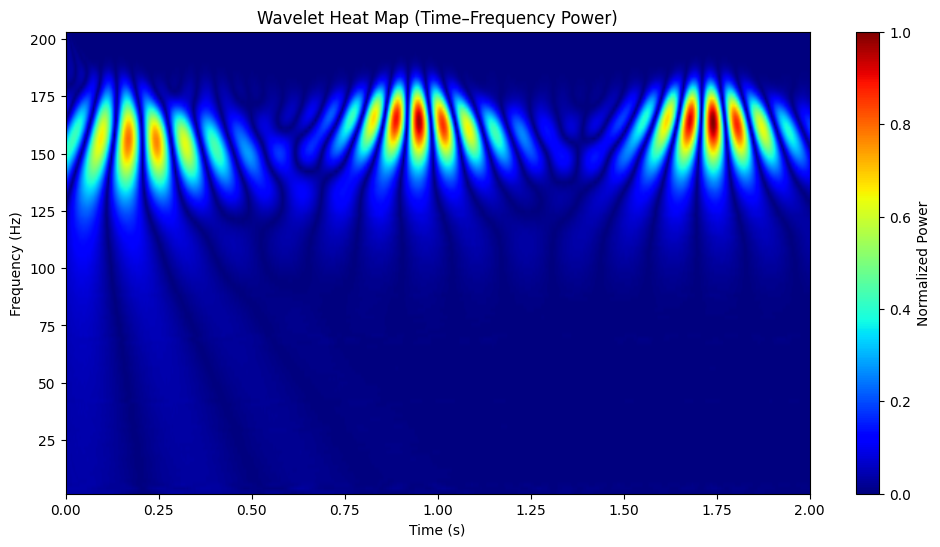

In [ ]:
import numpy as np
import pywt
import matplotlib.pyplot as plt

# ----------------------------------------------------
# Load your signal
# ----------------------------------------------------
signal = channel_data_filtered      # your filtered EEG/EMG channel
fs = 250                              # your sampling rate (Hz) — change if needed

# ----------------------------------------------------
# Define wavelet + scales
# ----------------------------------------------------
wavelet = 'morl'
scales = np.arange(1, 128)

# Compute scalogram
coeffs, freqs = pywt.cwt(signal, scales, wavelet, sampling_period=1/fs)

# Normalize coefficients for visualization
abs_coeffs = np.abs(coeffs)
norm_coeffs = (abs_coeffs - abs_coeffs.min()) / (abs_coeffs.max() - abs_coeffs.min())

# Time axis (in seconds)
time = np.arange(len(signal)) / fs

# ----------------------------------------------------
# Plot wavelet heat map with frequency axis
# ----------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6))

im = ax.imshow(
    norm_coeffs,
    extent=[time[0], time[-1], freqs[-1], freqs[0]],   # flip freq so low→high
    cmap='jet',
    aspect='auto',
    interpolation='bilinear'
)

ax.set_title('Wavelet Heat Map (Time–Frequency Power)')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Frequency (Hz)')
ax.set_xlim(0, 2)
#ax.set_ylim(195, 202)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Normalized Power')

plt.show()


This script provides methods for quantitative analysis of EMG signals using amplitude and power-based metrics. It computes the instantaneous root mean square (iRMS), total signal power, and integrated EMG (iEMG), which are commonly used to assess muscle activation intensity and overall neuromuscular activity.

The workflow consists of the following steps:

**Instantaneous RMS (iRMS) calculation**
The EMG signal is squared and convolved with a sliding window to compute the RMS over time. This produces a smoothed measure of muscle activation amplitude, highlighting transient bursts while reducing high-frequency noise.

**Total EMG power (20–450 Hz)**  
Using the Welch method, the power spectral density (PSD) of the EMG signal is calculated. The total power in the physiologically relevant EMG band (20–450 Hz) is integrated, providing a metric for the overall energy of the muscle activity.

**Integrated EMG (iEMG)**
The absolute values of the EMG signal are summed over time to obtain a single value representing cumulative muscle activity. This measure is useful for comparing total activation between conditions or muscles.

**Visualization**  
The script plots both the raw EMG signal and the iRMS trace, enabling visual assessment of activation patterns over time and the intensity of muscle contractions.

This approach provides a comprehensive framework for quantifying EMG amplitude and power, useful in neuromuscular studies, motor control analysis, fatigue assessment, and rehabilitation monitoring.

**NN interval**

In [ ]:
!pip install neurokit2

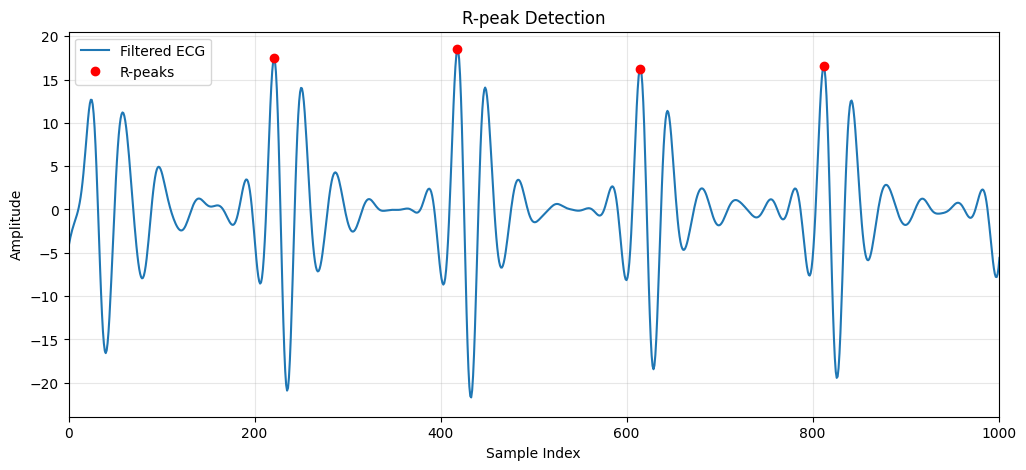

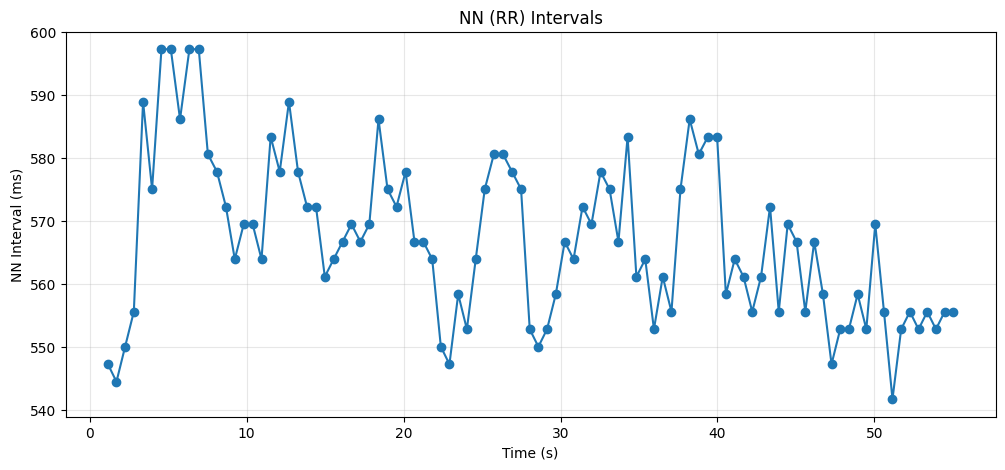

Total NN intervals: 96
Mean NN interval: 566.87 ms
SDNN: 12.96 ms
Min NN: 541.67 ms
Max NN: 597.22 ms


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import neurokit2 as nk

# Your filtered ECG signal
x = channel_data_filtered

# Sampling rate
fs = 360  # Hz

# Time axis
n_samples = len(x)
time = np.arange(n_samples)

# --- R-peak detection ---
signals, info = nk.ecg_process(x, sampling_rate=fs)
r_peaks = info["ECG_R_Peaks"]

# --- NN (RR) Intervals ---
# Differences between successive R-peaks (in samples)
nn_intervals_samples = np.diff(r_peaks)

# Convert to milliseconds
nn_intervals_ms = (nn_intervals_samples / fs) * 1000

# Time axis for NN intervals (aligned to R-peaks)
nn_time = r_peaks[1:] / fs  # seconds

# --- Plot ECG with R-peaks ---
plt.figure(figsize=(12, 5))
plt.plot(time, x, label="Filtered ECG")
plt.plot(r_peaks, x[r_peaks], 'ro', label="R-peaks")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.title("R-peak Detection")
plt.legend()
plt.xlim([0,1000])
plt.grid(alpha=0.3)
plt.show()

# --- Plot NN intervals ---
plt.figure(figsize=(12, 5))
plt.plot(nn_time, nn_intervals_ms, marker='o', linestyle='-')
plt.xlabel("Time (s)")
plt.ylabel("NN Interval (ms)")
plt.title("NN (RR) Intervals")
#plt.xlim([0,1000])
plt.grid(alpha=0.3)
plt.show()

# --- Basic NN statistics ---
print(f"Total NN intervals: {len(nn_intervals_ms)}")
print(f"Mean NN interval: {np.mean(nn_intervals_ms):.2f} ms")
print(f"SDNN: {np.std(nn_intervals_ms, ddof=1):.2f} ms")
print(f"Min NN: {np.min(nn_intervals_ms):.2f} ms")
print(f"Max NN: {np.max(nn_intervals_ms):.2f} ms")


**The end of the chapter 2**